<a href="https://colab.research.google.com/github/Pazidu/Research-Project/blob/main/experiment20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import random
import warnings
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from tensorflow import keras as tf_keras

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("V20 MELANOMA CLASSIFICATION")
print("=" * 70)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

print("=" * 70)

V20 MELANOMA CLASSIFICATION
TensorFlow: 2.20.0
Keras: 3.13.2


In [2]:
from google.colab import drive

print("=" * 70)
print("MOUNTING GOOGLE DRIVE")
print("=" * 70)

drive.mount("/content/drive")

print("\nGoogle Drive mounted successfully.")

print("\nMyDrive contents:")

for item in os.listdir("/content/drive/MyDrive")[:30]:
    print(" -", item)


MOUNTING GOOGLE DRIVE
Mounted at /content/drive

Google Drive mounted successfully.

MyDrive contents:
 - 2021CSC064 Wilagama.pdf
 - G chat
 - Python
 - my-cv.pdf
 - Laravel-Coding-Session
 - Laravel-Coding-Session.zip
 - matlab.zip
 - public.zip
 - Untitled2.zip
 - matlab
 - prolog
 - linux
 - Ivana
 - Cisco networking
 - openmp (1)
 - research
 - openmp
 - Deep learning
 - can you give a table type, these data for add my....gsheet
 - use this also and give abouve data..gsheet
 - My topic is Improving Generalization of Melanoma....gsheet
 - Improving Generalization of Melanoma Detection Across Multiple Datasets Using Deep Learning and Domain Adaptation Techniques (2).gdoc
 - Improving Generalization of Melanoma Detection Across Multiple Datasets Using Deep Learning and Domain Adaptation Techniques (1).gdoc
 - Improving Generalization of Melanoma Detection Across Multiple Datasets Using Deep Learning and Domain Adaptation Techniques.gdoc
 - I found related research papaers.
refer them 

In [3]:
# ================================================================
# CELL 3 - REPRODUCIBILITY
# ================================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Random seed:", SEED)

# ================================================================
# CELL 4 - GPU CHECK
# ================================================================

print("\n" + "=" * 70)
print("GPU INFORMATION")
print("=" * 70)

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print("GPU detected:")

    for gpu in gpus:
        print(" ", gpu)

    try:

        for gpu in gpus:

            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

    except Exception as e:

        print(
            "Memory growth warning:",
            e
        )

else:

    print("WARNING: No GPU detected.")

    print(
        "Go to Runtime > Change runtime type > GPU."
    )

# ================================================================
# CELL 5 - V20 DATASET CONFIGURATION
# ================================================================

print("\n" + "=" * 70)
print("V20 DATASET CONFIGURATION")
print("=" * 70)


# ------------------------------------------------
# GOOGLE DRIVE DATASET SOURCE
# ------------------------------------------------

IMG_SRC = (
    "/content/drive/MyDrive/"
    "Colab Notebooks/newdata_backup"
)


# ------------------------------------------------
# LOCAL COLAB DATASET
# ------------------------------------------------

DATASET = "/content/newdata"


# ------------------------------------------------
# IMPORTANT DATASET ROOT
# ------------------------------------------------

DATASET_ROOT = DATASET


# ------------------------------------------------
# CLASS NAMES
# ------------------------------------------------

CLASS_NAMES = [
    "non_melanoma",
    "melanoma"
]


# ------------------------------------------------
# IMAGE SETTINGS
# ------------------------------------------------

IMG_SIZE = 300

BATCH_SIZE = 4

AUTOTUNE = tf.data.AUTOTUNE


# ------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------

STAGE1_EPOCHS = 12

STAGE2_EPOCHS = 10


# ------------------------------------------------
# LEARNING RATES
# ------------------------------------------------

STAGE1_LR = 1e-4

STAGE2_LR = 5e-6

MIN_LR = 1e-7


# ------------------------------------------------
# V20 MELANOMA WEIGHT
# ------------------------------------------------

NON_MELANOMA_WEIGHT = 1.0

MELANOMA_WEIGHT = 1.50

# V20 focal-loss focusing parameter
FOCAL_GAMMA = 1.0


# ------------------------------------------------
# FINE-TUNING
# ------------------------------------------------

FINE_TUNE_FRACTION = 0.35


# ------------------------------------------------
# V20 THRESHOLD POLICY
# ------------------------------------------------

MIN_REQUIRED_SENSITIVITY = 0.70


print("Drive dataset source:")
print(IMG_SRC)

print("\nLocal Colab dataset:")
print(DATASET)

print("\nClass names:")
print(CLASS_NAMES)

print("\nImage size:", IMG_SIZE)

print("Batch size:", BATCH_SIZE)

print("Non-melanoma weight:", NON_MELANOMA_WEIGHT)

print("Melanoma weight:", MELANOMA_WEIGHT)
print("Focal gamma:", FOCAL_GAMMA)

print(
    "Minimum required sensitivity:",
    MIN_REQUIRED_SENSITIVITY
)

# ================================================================
# CELL 6 - DATASET STRUCTURE CHECK
# ================================================================

print("\n" + "=" * 70)
print("CHECKING SOURCE DATASET")
print("=" * 70)


def has_required_dataset_structure(path):

    required_splits = [
        "train",
        "valid",
        "test"
    ]

    required_classes = [
        "melanoma",
        "non_melanoma"
    ]

    if not os.path.isdir(path):
        return False

    for split in required_splits:

        split_path = os.path.join(
            path,
            split
        )

        if not os.path.isdir(split_path):
            return False

        for class_name in required_classes:

            class_path = os.path.join(
                split_path,
                class_name
            )

            if not os.path.isdir(class_path):
                return False

    return True


print("Checking:")

print(IMG_SRC)


if not os.path.exists(IMG_SRC):

    raise FileNotFoundError(

        "Dataset source was not found:\n\n"
        f"{IMG_SRC}\n\n"

        "Expected structure:\n"

        "newdata_backup/\n"
        "  train/\n"
        "    melanoma/\n"
        "    non_melanoma/\n"
        "  valid/\n"
        "    melanoma/\n"
        "    non_melanoma/\n"
        "  test/\n"
        "    melanoma/\n"
        "    non_melanoma/"
    )


if not has_required_dataset_structure(IMG_SRC):

    raise FileNotFoundError(

        "Dataset exists, but the required "
        "directory structure was not found.\n\n"

        f"Dataset: {IMG_SRC}"
    )


print("\nSource dataset structure verified.")


Random seed: 42

GPU INFORMATION
GPU detected:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

V20 DATASET CONFIGURATION
Drive dataset source:
/content/drive/MyDrive/Colab Notebooks/newdata_backup

Local Colab dataset:
/content/newdata

Class names:
['non_melanoma', 'melanoma']

Image size: 300
Batch size: 4
Non-melanoma weight: 1.0
Melanoma weight: 1.5
Focal gamma: 1.0
Minimum required sensitivity: 0.7

CHECKING SOURCE DATASET
Checking:
/content/drive/MyDrive/Colab Notebooks/newdata_backup

Source dataset structure verified.


In [4]:
# ================================================================
# CELL 7 - COPY DATASET TO LOCAL COLAB STORAGE
# ================================================================

print("\n" + "=" * 70)
print("COPYING DATASET TO LOCAL COLAB STORAGE")
print("=" * 70)


# ------------------------------------------------
# REMOVE EXISTING LOCAL DATASET
# ------------------------------------------------

if os.path.exists(DATASET):

    print("Removing existing local dataset...")

    shutil.rmtree(DATASET)


# ------------------------------------------------
# COPY DATASET
# ------------------------------------------------

print("\nCopying dataset:")

print("FROM:")
print(IMG_SRC)

print("\nTO:")
print(DATASET)


shutil.copytree(
    IMG_SRC,
    DATASET
)


# ------------------------------------------------
# VERIFY COPIED DATASET
# ------------------------------------------------

if not has_required_dataset_structure(DATASET):

    raise FileNotFoundError(

        "The copied local dataset does not have "
        "the required directory structure.\n\n"

        f"Dataset: {DATASET}"
    )


print("\nLocal dataset copied successfully.")

print("Local dataset structure verified.")


COPYING DATASET TO LOCAL COLAB STORAGE

Copying dataset:
FROM:
/content/drive/MyDrive/Colab Notebooks/newdata_backup

TO:
/content/newdata

Local dataset copied successfully.
Local dataset structure verified.


In [5]:
# ================================================================
# CELL 8 - DATASET PATHS
# ================================================================

TRAIN_DIR = os.path.join(
    DATASET,
    "train"
)

VALID_DIR = os.path.join(
    DATASET,
    "valid"
)

TEST_DIR = os.path.join(
    DATASET,
    "test"
)


print("=" * 70)
print("FINAL DATASET PATHS")
print("=" * 70)

print("Source:")
print(IMG_SRC)

print("\nLocal dataset:")
print(DATASET)

print("\nTrain:")
print(TRAIN_DIR)

print("\nValid:")
print(VALID_DIR)

print("\nTest:")
print(TEST_DIR)

# ================================================================
# CELL 9 - OUTPUT DIRECTORIES
# ================================================================

CHECKPOINT_DIR = (
    "/content/drive/MyDrive/checkpoints"
)


MODEL_DIR = (
    "/content/drive/MyDrive/"
    "Colab Notebooks/Models/dermoscopy"
)


os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


MODEL_NAME = "efficientnet_v20"


BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    MODEL_NAME + "_best.keras"
)


FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_final.keras"
)


THRESHOLD_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_threshold.txt"
)


RESULTS_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_results.json"
)


ROC_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_roc_data.json"
)


PR_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_pr_data.json"
)


CM_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_confusion_matrix.json"
)


REPORT_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_classification_report.txt"
)


THRESHOLD_RESULTS_PATH = os.path.join(
    MODEL_DIR,
    MODEL_NAME + "_threshold_results.csv"
)


print("=" * 70)
print("V20 OUTPUT PATHS")
print("=" * 70)

print("Checkpoint:")
print(BEST_MODEL_PATH)

print("\nFinal model:")
print(FINAL_MODEL_PATH)

print("\nThreshold:")
print(THRESHOLD_PATH)

print("\nResults:")
print(RESULTS_PATH)

# ================================================================
# CELL 10 - CHECK DATASET DIRECTORIES
# ================================================================

print("\n" + "=" * 70)
print("CHECKING DATASET DIRECTORIES")
print("=" * 70)


for directory in [
    TRAIN_DIR,
    VALID_DIR,
    TEST_DIR
]:

    if not os.path.exists(directory):

        raise FileNotFoundError(
            f"Dataset directory not found:\n{directory}"
        )

    print("OK:", directory)


print("\nDataset directory structure:")

for split in [
    "train",
    "valid",
    "test"
]:

    split_path = os.path.join(
        DATASET,
        split
    )

    print(f"\n{split.upper()}:")

    for class_name in CLASS_NAMES:

        class_path = os.path.join(
            split_path,
            class_name
        )

        print(
            "  ",
            class_name,
            "->",
            class_path
        )

# ================================================================
# CELL 11 - DATASET COUNTS
# ================================================================

def count_images(directory):

    counts = {
        "melanoma": 0,
        "non_melanoma": 0
    }

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp"
    }

    for class_name in counts:

        class_dir = os.path.join(
            directory,
            class_name
        )

        if not os.path.exists(class_dir):

            print(
                "WARNING: missing class:",
                class_dir
            )

            continue

        for root, _, files in os.walk(
            class_dir
        ):

            for file in files:

                if Path(
                    file
                ).suffix.lower() in extensions:

                    counts[
                        class_name
                    ] += 1

    return counts


train_counts = count_images(
    TRAIN_DIR
)

valid_counts = count_images(
    VALID_DIR
)

test_counts = count_images(
    TEST_DIR
)


print("\n" + "=" * 70)
print("V20 DATASET COUNTS")
print("=" * 70)


for name, counts in [
    ("TRAIN", train_counts),
    ("VALID", valid_counts),
    ("TEST", test_counts)
]:

    print(f"\n{name}")

    print(
        "melanoma:",
        counts["melanoma"]
    )

    print(
        "non_melanoma:",
        counts["non_melanoma"]
    )

    print(
        "total:",
        counts["melanoma"] +
        counts["non_melanoma"]
    )

# ================================================================
# CELL 12 - CREATE DATASETS
# ================================================================

print("\n" + "=" * 70)
print("CREATING DATASETS")
print("=" * 70)


train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="binary",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


valid_ds = tf.keras.utils.image_dataset_from_directory(

    VALID_DIR,

    labels="inferred",

    label_mode="binary",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="binary",

    class_names=CLASS_NAMES,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    shuffle=False
)


print("\nClass names:")
print(CLASS_NAMES)


print("\nIMPORTANT LABEL MAPPING")

print("0 = non_melanoma")

print("1 = melanoma")

print("MODEL OUTPUT = P(melanoma)")

# ================================================================
# CELL 13 - PERFORMANCE SETTINGS
# ================================================================

train_ds = train_ds.prefetch(
    AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)


print(
    "Dataset prefetching enabled."
)

# ================================================================
# CELL 14 - V20 DATA AUGMENTATION
# ================================================================

print("\n" + "=" * 70)
print("CREATING V20 DATA AUGMENTATION")
print("=" * 70)


data_augmentation = tf.keras.Sequential(

    [

        tf.keras.layers.RandomFlip(
            mode="horizontal_and_vertical"
        ),

        tf.keras.layers.RandomRotation(
            factor=0.08
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),

        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),

        tf.keras.layers.RandomContrast(
            factor=0.10
        ),

        # ------------------------------------------------
        # V20 controlled augmentation
        # ------------------------------------------------

        tf.keras.layers.RandomBrightness(
            factor=0.08
        )

    ],

    name="v20_augmentation"
)


print(
    "V20 augmentation created."
)

print(
    "Additional augmentation:",
    "RandomBrightness(0.08)"
)

# ================================================================
# CELL 15 - V20 WEIGHTED FOCAL LOSS
# ================================================================

@tf.keras.utils.register_keras_serializable()
class MelanomaWeightedFocalLoss(
    tf.keras.losses.Loss
):

    def __init__(
        self,
        non_melanoma_weight=1.0,
        melanoma_weight=1.50,
        gamma=FOCAL_GAMMA,
        name="melanoma_weighted_focal_loss",
        **kwargs
    ):
        super().__init__(
            name=name,
            **kwargs
        )

        self.non_melanoma_weight = float(
            non_melanoma_weight
        )

        self.melanoma_weight = float(
            melanoma_weight
        )

        self.gamma = float(gamma)


    def call(
        self,
        y_true,
        y_pred
    ):
        y_true = tf.cast(
            y_true,
            tf.float32
        )

        y_pred = tf.cast(
            y_pred,
            tf.float32
        )

        epsilon = tf.keras.backend.epsilon()

        y_pred = tf.clip_by_value(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        # Binary cross-entropy for each sample.
        bce = -(
            y_true * tf.math.log(y_pred)
            +
            (1.0 - y_true) *
            tf.math.log(1.0 - y_pred)
        )

        # p_t is the probability assigned to the true class.
        p_t = (
            y_true * y_pred
            +
            (1.0 - y_true) * (1.0 - y_pred)
        )

        # Focal modulation down-weights easy, confidently
        # classified examples and concentrates the loss on
        # difficult examples. gamma=1 is the controlled V20 focal-loss
        # experiment following V18 gamma=2.
        focal_factor = tf.pow(
            1.0 - p_t,
            self.gamma
        )

        # Preserve V17's clinically motivated melanoma emphasis.
        class_weights = (
            y_true * self.melanoma_weight
            +
            (1.0 - y_true) * self.non_melanoma_weight
        )

        return (
            bce
            * focal_factor
            * class_weights
        )


    def get_config(self):
        config = super().get_config()

        config.update({
            "non_melanoma_weight":
                self.non_melanoma_weight,
            "melanoma_weight":
                self.melanoma_weight,
            "gamma":
                self.gamma
        })

        return config

# ================================================================
# CELL 16 - METRICS
# ================================================================

def create_metrics():

    return [

        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )

    ]


print(
    "Metrics configured."
)

# ================================================================
# CELL 17 - CREATE V20 MODEL
# ================================================================

print("\n" + "=" * 70)
print("CREATING V20 MODEL")
print("=" * 70)


inputs = tf.keras.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    name="image"
)


x = data_augmentation(
    inputs
)


backbone = tf.keras.applications.EfficientNetV2S(

    include_top=False,

    weights="imagenet",

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    pooling=None,

    include_preprocessing=True,

    name="efficientnetv2-s"
)


backbone.trainable = False


x = backbone(
    x,
    training=False
)


x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)


x = tf.keras.layers.Dropout(
    0.35,
    name="dropout_1"
)(x)


x = tf.keras.layers.Dense(
    128,
    activation="swish",
    name="classifier_dense"
)(x)


x = tf.keras.layers.Dropout(
    0.25,
    name="dropout_2"
)(x)


outputs = tf.keras.layers.Dense(

    1,

    activation="sigmoid",

    name="melanoma_probability"

)(x)


model = tf.keras.Model(

    inputs=inputs,

    outputs=outputs,

    name="efficientnet_v20"

)


print("\nModel created successfully.")

print(
    "Model:",
    model.name
)

print(
    "Backbone:",
    backbone.name
)

print(
    "Melanoma weight:",
    MELANOMA_WEIGHT
)

print(
    "Focal gamma:",
    FOCAL_GAMMA
)

# ================================================================
# CELL 18 - MODEL SUMMARY
# ================================================================

model.summary()

# ================================================================
# CELL 19 - COMPILE STAGE 1
# ================================================================

print("\n" + "=" * 70)
print("COMPILING V20 STAGE 1")
print("=" * 70)


loss_fn = MelanomaWeightedFocalLoss(

    non_melanoma_weight=
        NON_MELANOMA_WEIGHT,

    melanoma_weight=
        MELANOMA_WEIGHT
)


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=
            STAGE1_LR

    ),

    loss=loss_fn,

    metrics=create_metrics()

)


print("Stage 1 compiled.")

print(
    "Learning rate:",
    STAGE1_LR
)

# ================================================================
# CELL 20 - STAGE 1 CALLBACKS
# ================================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(

    BEST_MODEL_PATH,

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_auc",

    mode="max",

    factor=0.5,

    patience=2,

    min_lr=MIN_LR,

    verbose=1
)


early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=5,

    restore_best_weights=True,

    verbose=1
)


print(
    "Stage 1 callbacks ready."
)


FINAL DATASET PATHS
Source:
/content/drive/MyDrive/Colab Notebooks/newdata_backup

Local dataset:
/content/newdata

Train:
/content/newdata/train

Valid:
/content/newdata/valid

Test:
/content/newdata/test
V20 OUTPUT PATHS
Checkpoint:
/content/drive/MyDrive/checkpoints/efficientnet_v20_best.keras

Final model:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_final.keras

Threshold:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_threshold.txt

Results:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_results.json

CHECKING DATASET DIRECTORIES
OK: /content/newdata/train
OK: /content/newdata/valid
OK: /content/newdata/test

Dataset directory structure:

TRAIN:
   non_melanoma -> /content/newdata/train/non_melanoma
   melanoma -> /content/newdata/train/melanoma

VALID:
   non_melanoma -> /content/newdata/valid/non_melanoma
   melanoma -> /content/newdata/valid/melanoma

TEST:
   non_melanoma -> /content/newdata/te

Model: "efficientnet_v20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ v20_augmentation (Sequential)   │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ melanoma_probability (Dense)    │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,495,457 (78.18 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 20,331,360 (77.56 MB)


COMPILING V20 STAGE 1
Stage 1 compiled.
Learning rate: 0.0001
Stage 1 callbacks ready.


In [6]:
print("\n")
print("=" * 70)
print("V20 STAGE 1 - FROZEN EFFICIENTNETV2-S")
print("=" * 70)


print(
    "Melanoma loss weight:",
    MELANOMA_WEIGHT
)

print(
    "Backbone trainable:",
    backbone.trainable
)

print(
    "Stage 1 epochs:",
    STAGE1_EPOCHS
)


history_stage1 = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=STAGE1_EPOCHS,

    callbacks=[

        checkpoint,

        reduce_lr,

        early_stop

    ],

    verbose=1
)




V20 STAGE 1 - FROZEN EFFICIENTNETV2-S
Melanoma loss weight: 1.5
Backbone trainable: False
Stage 1 epochs: 12
Epoch 1/12
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8179 - auc: 0.9094 - loss: 0.2281 - pr_auc: 0.9203 - precision: 0.8053 - recall: 0.8307
Epoch 1: val_auc improved from None to 0.80053, saving model to /content/drive/MyDrive/checkpoints/efficientnet_v20_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/efficientnet_v20_best.keras
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 270s 68ms/step - accuracy: 0.8304 - auc: 0.9253 - loss: 0.2087 - pr_auc: 0.9365 - precision: 0.8174 - recall: 0.8509 - val_accuracy: 0.8192 - val_auc: 0.8005 - val_loss: 0.2192 - val_pr_auc: 0.3175 - val_precision: 0.3138 - val_recall: 0.5315 - learning_rate: 1.0000e-04
Epoch 2/12
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8370 - auc: 0.9356 - loss: 0.1930 - pr_auc: 0.9446 - precision: 0.8218 - recall: 0.8582
Epoch 2: val_auc improved from 0.80053 to 0.8023

In [7]:
# ================================================================
# CELL 22 - LOAD BEST STAGE 1 MODEL
# ================================================================

print("\n" + "=" * 70)
print("LOADING BEST V20 STAGE 1 MODEL")
print("=" * 70)


best_stage1_model = tf.keras.models.load_model(

    BEST_MODEL_PATH,

    compile=False
)


print(
    "Best Stage 1 model loaded."
)


backbone = best_stage1_model.get_layer(
    "efficientnetv2-s"
)


model = best_stage1_model


print(
    "Backbone found:",
    backbone.name
)

# ================================================================
# CELL 23 - FINE-TUNING SETUP
# ================================================================

print("\n" + "=" * 70)
print("PREPARING V20 FINE-TUNING")
print("=" * 70)


backbone.trainable = True


total_layers = len(
    backbone.layers
)


fine_tune_from = int(

    total_layers *
    (1.0 - FINE_TUNE_FRACTION)

)


print(
    "Total backbone layers:",
    total_layers
)

print(
    "Fine-tuning from layer:",
    fine_tune_from
)


# ------------------------------------------------
# Freeze everything
# ------------------------------------------------

for layer in backbone.layers:

    layer.trainable = False


# ------------------------------------------------
# Unfreeze final portion
# ------------------------------------------------

for layer in backbone.layers[
    fine_tune_from:
]:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


trainable_count = sum(

    1
    for layer in backbone.layers
    if layer.trainable

)


print(
    "Trainable backbone layers:",
    trainable_count
)

# ================================================================
# CELL 24 - COMPILE STAGE 2
# ================================================================

print("\n" + "=" * 70)
print("COMPILING V20 STAGE 2")
print("=" * 70)


model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=
            STAGE2_LR

    ),

    loss=MelanomaWeightedFocalLoss(

        non_melanoma_weight=
            NON_MELANOMA_WEIGHT,

        melanoma_weight=
            MELANOMA_WEIGHT

    ),

    metrics=create_metrics()

)


print("Stage 2 compiled.")

print(
    "Learning rate:",
    STAGE2_LR
)

# ================================================================
# CELL 25 - STAGE 2 CALLBACKS
# ================================================================

checkpoint_stage2 = tf.keras.callbacks.ModelCheckpoint(

    BEST_MODEL_PATH,

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


reduce_lr_stage2 = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_auc",

    mode="max",

    factor=0.5,

    patience=2,

    min_lr=MIN_LR,

    verbose=1
)


early_stop_stage2 = tf.keras.callbacks.EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=4,

    restore_best_weights=True,

    verbose=1
)


print(
    "Stage 2 callbacks ready."
)



LOADING BEST V20 STAGE 1 MODEL
Best Stage 1 model loaded.
Backbone found: efficientnetv2-s

PREPARING V20 FINE-TUNING
Total backbone layers: 513
Fine-tuning from layer: 333
Trainable backbone layers: 144

COMPILING V20 STAGE 2
Stage 2 compiled.
Learning rate: 5e-06
Stage 2 callbacks ready.


In [8]:
print("\n")
print("=" * 70)
print("V20 STAGE 2 - FINE-TUNING EFFICIENTNETV2-S")
print("=" * 70)


print(
    "Trainable backbone layers:",
    trainable_count
)

print(
    "Fine-tuning learning rate:",
    STAGE2_LR
)

print(
    "Stage 2 epochs:",
    STAGE2_EPOCHS
)


history_stage2 = model.fit(

    train_ds,

    validation_data=valid_ds,

    epochs=STAGE2_EPOCHS,

    callbacks=[

        checkpoint_stage2,

        reduce_lr_stage2,

        early_stop_stage2

    ],

    verbose=1
)



V20 STAGE 2 - FINE-TUNING EFFICIENTNETV2-S
Trainable backbone layers: 144
Fine-tuning learning rate: 5e-06
Stage 2 epochs: 10
Epoch 1/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8707 - auc: 0.9571 - loss: 0.1572 - pr_auc: 0.9624 - precision: 0.8604 - recall: 0.8846
Epoch 1: val_auc improved from None to 0.83873, saving model to /content/drive/MyDrive/checkpoints/efficientnet_v20_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/efficientnet_v20_best.keras
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 379s 97ms/step - accuracy: 0.8730 - auc: 0.9585 - loss: 0.1552 - pr_auc: 0.9638 - precision: 0.8607 - recall: 0.8901 - val_accuracy: 0.8462 - val_auc: 0.8387 - val_loss: 0.1966 - val_pr_auc: 0.4042 - val_precision: 0.3697 - val_recall: 0.5495 - learning_rate: 5.0000e-06
Epoch 2/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8903 - auc: 0.9669 - loss: 0.1401 - pr_auc: 0.9705 - precision: 0.8777 - recall: 0.9065
Epoch 2: val_auc improved from 



LOADING ABSOLUTE BEST V20 MODEL
Absolute best V20 model loaded.


V20 VALIDATION PREDICTIONS
Validation samples: 1001
Validation melanoma: 111
Validation non-melanoma: 890

V20 VALIDATION PERFORMANCE
Validation ROC-AUC: 0.8795
Validation PR-AUC: 0.5034


V20 VALIDATION THRESHOLD SEARCH

Best accuracy:
{'threshold': 0.71, 'accuracy': 0.906093906093906, 'precision': 0.6268656716417911, 'sensitivity': 0.3783783783783784, 'specificity': 0.9719101123595506, 'f1': 0.47191011235955055, 'balanced_accuracy': 0.6751442453689644, 'youden_j': 0.3502884907379289, 'tn': 865.0, 'fp': 25.0, 'fn': 69.0, 'tp': 42.0}

Best F1:
{'threshold': 0.56, 'accuracy': 0.8831168831168831, 'precision': 0.4788732394366197, 'sensitivity': 0.6126126126126126, 'specificity': 0.9168539325842696, 'f1': 0.5375494071146245, 'balanced_accuracy': 0.764733272598441, 'youden_j': 0.5294665451968821, 'tn': 816.0, 'fp': 74.0, 'fn': 43.0, 'tp': 68.0}

Best balanced accuracy:
{'threshold': 0.195, 'accuracy': 0.7092907092907093, 'p

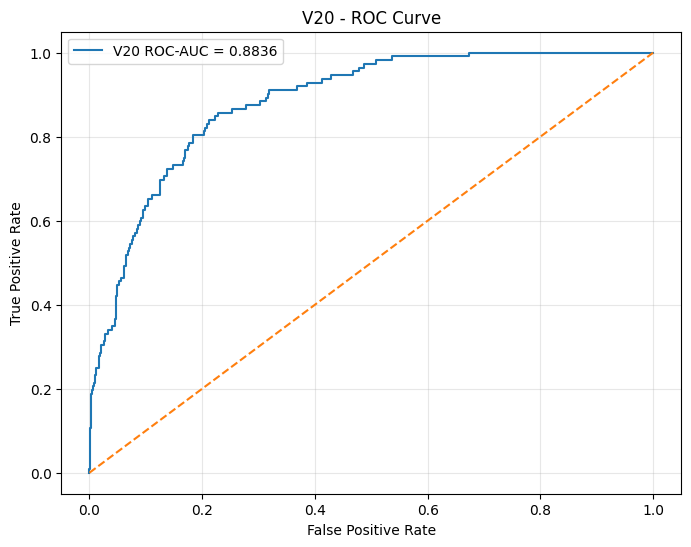

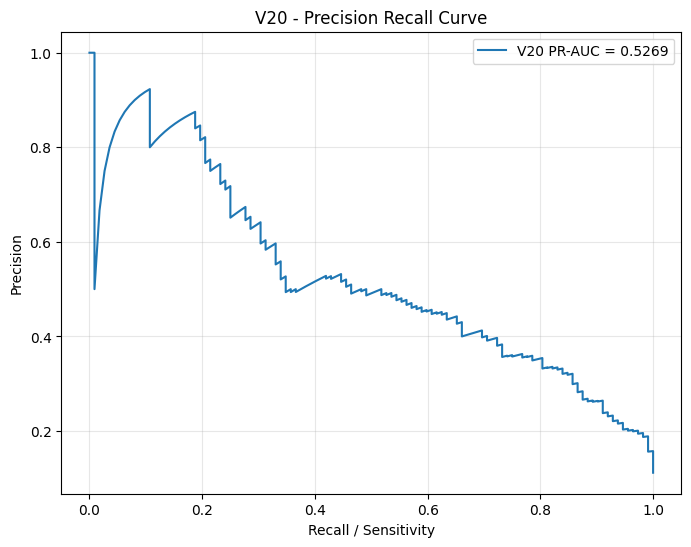

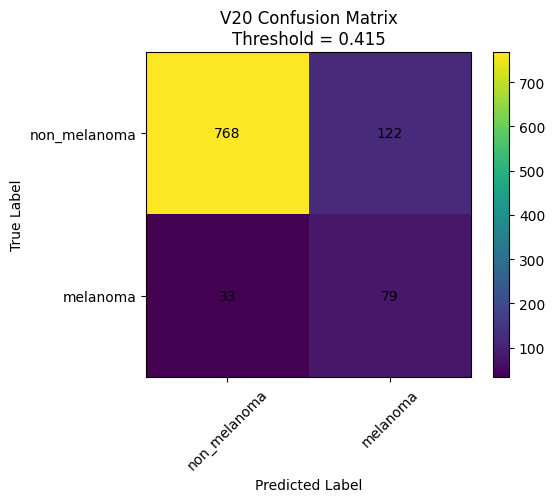

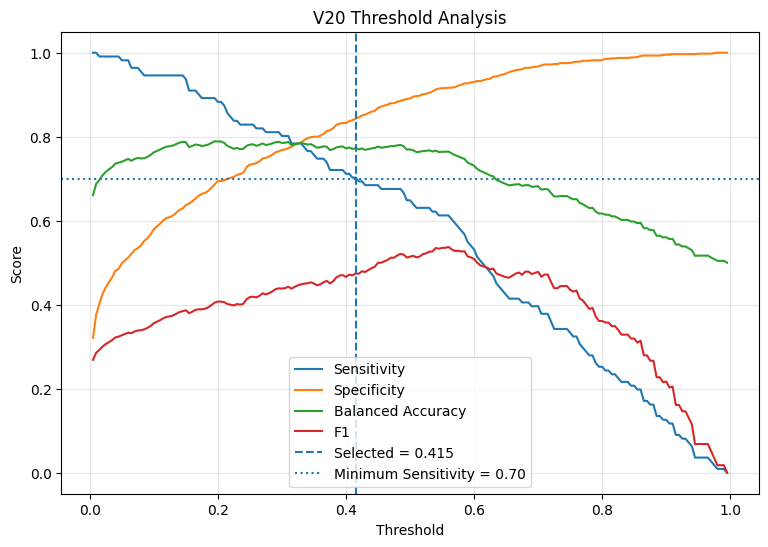

ROC data saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_roc_data.json
PR data saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_pr_data.json
Confusion matrix saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_confusion_matrix.json
Classification report saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_classification_report.txt
Threshold saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_threshold.txt
Threshold results saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_threshold_results.csv
Experiment summary saved:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_results.json


SAVING FINAL V20 MODEL
V20 MODEL SAVED:
/content/drive/MyDrive/Colab Notebooks/Models/dermoscopy/efficientnet_v20_final.keras


V14 VS V16 VS V17 VS V18 VS V20
                     V14    V16    V17    V1

In [9]:
print("\n")
print("=" * 70)
print("LOADING ABSOLUTE BEST V20 MODEL")
print("=" * 70)


best_model = tf.keras.models.load_model(

    BEST_MODEL_PATH,

    compile=False
)


print(
    "Absolute best V20 model loaded."
)

# ================================================================
# CELL 28 - PREDICTION FUNCTION
# ================================================================

def get_predictions(
    model,
    dataset
):

    probabilities = []

    labels = []


    for images, batch_labels in dataset:

        batch_predictions = model.predict(

            images,

            verbose=0

        )


        probabilities.extend(

            batch_predictions.reshape(-1)

        )


        labels.extend(

            batch_labels.numpy().reshape(-1)

        )


    probabilities = np.asarray(

        probabilities,

        dtype=np.float32

    )


    labels = np.asarray(

        labels,

        dtype=np.int32

    )


    return labels, probabilities

# ================================================================
# CELL 29 - V20 VALIDATION PREDICTIONS
# ================================================================

print("\n")
print("=" * 70)
print("V20 VALIDATION PREDICTIONS")
print("=" * 70)


y_val, p_val = get_predictions(

    best_model,

    valid_ds

)


print(
    "Validation samples:",
    len(y_val)
)

print(
    "Validation melanoma:",
    int(np.sum(y_val == 1))
)

print(
    "Validation non-melanoma:",
    int(np.sum(y_val == 0))
)

# ================================================================
# CELL 30 - V20 VALIDATION PERFORMANCE
# ================================================================

print("\n" + "=" * 70)
print("V20 VALIDATION PERFORMANCE")
print("=" * 70)


val_roc_auc = roc_auc_score(

    y_val,

    p_val

)


val_pr_auc = average_precision_score(

    y_val,

    p_val

)


print(
    "Validation ROC-AUC:",
    f"{val_roc_auc:.4f}"
)


print(
    "Validation PR-AUC:",
    f"{val_pr_auc:.4f}"
)

# ================================================================
# CELL 31 - THRESHOLD EVALUATION
# ================================================================

def evaluate_threshold(

    y_true,

    probabilities,

    threshold

):

    predictions = (

        probabilities >= threshold

    ).astype(int)


    tn, fp, fn, tp = confusion_matrix(

        y_true,

        predictions,

        labels=[0, 1]

    ).ravel()


    accuracy = accuracy_score(

        y_true,

        predictions

    )


    precision = precision_score(

        y_true,

        predictions,

        zero_division=0

    )


    sensitivity = recall_score(

        y_true,

        predictions,

        zero_division=0

    )


    specificity = (

        tn / (tn + fp)

        if (tn + fp) > 0

        else 0

    )


    f1 = f1_score(

        y_true,

        predictions,

        zero_division=0

    )


    balanced = balanced_accuracy_score(

        y_true,

        predictions

    )


    youden_j = (

        sensitivity +

        specificity -

        1.0

    )


    return {

        "threshold": float(threshold),

        "accuracy": float(accuracy),

        "precision": float(precision),

        "sensitivity": float(sensitivity),

        "specificity": float(specificity),

        "f1": float(f1),

        "balanced_accuracy": float(balanced),

        "youden_j": float(youden_j),

        "tn": int(tn),

        "fp": int(fp),

        "fn": int(fn),

        "tp": int(tp)

    }

# ================================================================
# CELL 32 - V20 VALIDATION THRESHOLD SEARCH
# ================================================================

print("\n")
print("=" * 70)
print("V20 VALIDATION THRESHOLD SEARCH")
print("=" * 70)


thresholds = np.arange(

    0.005,

    1.000,

    0.005

)


threshold_results = []


for threshold in thresholds:

    result = evaluate_threshold(

        y_val,

        p_val,

        threshold

    )

    threshold_results.append(
        result
    )


threshold_df = pd.DataFrame(
    threshold_results
)


best_accuracy_row = threshold_df.loc[

    threshold_df["accuracy"].idxmax()

]


best_f1_row = threshold_df.loc[

    threshold_df["f1"].idxmax()

]


best_balanced_row = threshold_df.loc[

    threshold_df["balanced_accuracy"].idxmax()

]


best_youden_row = threshold_df.loc[

    threshold_df["youden_j"].idxmax()

]


print("\nBest accuracy:")

print(
    best_accuracy_row.to_dict()
)


print("\nBest F1:")

print(
    best_f1_row.to_dict()
)


print("\nBest balanced accuracy:")

print(
    best_balanced_row.to_dict()
)


print("\nBest Youden J:")

print(
    best_youden_row.to_dict()
)

# ================================================================
# CELL 33 - V20 SENSITIVITY-CONSTRAINED SEARCH
# ================================================================

print("\n")
print("=" * 70)
print("V20 SENSITIVITY-CONSTRAINED THRESHOLD SEARCH")
print("=" * 70)


sensitivity_targets = [

    0.70,

    0.75,

    0.80,

    0.85,

    0.90,

    0.95

]


sensitivity_thresholds = {}


for target in sensitivity_targets:

    eligible = threshold_df[

        threshold_df["sensitivity"] >= target

    ]


    if len(eligible) == 0:

        print(

            f"{int(target * 100)}% sensitivity "
            "-> no threshold found"

        )

        continue


    best = eligible.loc[

        eligible["specificity"].idxmax()

    ]


    sensitivity_thresholds[
        int(target * 100)
    ] = best.to_dict()


    print(

        f"{int(target * 100)}% sensitivity -> "

        f"threshold={best['threshold']:.3f}, "

        f"sensitivity={best['sensitivity']:.4f}, "

        f"specificity={best['specificity']:.4f}, "

        f"precision={best['precision']:.4f}, "

        f"F1={best['f1']:.4f}, "

        f"balanced={best['balanced_accuracy']:.4f}"

    )

# ================================================================
# CELL 34 - SELECT FINAL V20 THRESHOLD
# ================================================================

print("\n")
print("=" * 70)
print("SELECTING V20 FINAL THRESHOLD")
print("=" * 70)


# ------------------------------------------------
# Minimum sensitivity requirement
# ------------------------------------------------

minimum_sensitivity = (
    MIN_REQUIRED_SENSITIVITY
)


# ------------------------------------------------
# Eligible thresholds
# ------------------------------------------------

eligible_f1 = threshold_df[

    threshold_df["sensitivity"]
    >= minimum_sensitivity

]


if len(eligible_f1) == 0:

    raise RuntimeError(

        "No validation threshold satisfies "
        f"sensitivity >= {minimum_sensitivity:.2f}"
    )


# ------------------------------------------------
# IMPORTANT:
# Maximize F1 while maintaining >=70% sensitivity
# ------------------------------------------------

best_constrained_f1 = eligible_f1.loc[

    eligible_f1["f1"].idxmax()

]


FINAL_THRESHOLD = float(

    best_constrained_f1["threshold"]

)


THRESHOLD_REASON = (

    "maximum validation F1 subject to "
    "validation sensitivity >= 70%"
)


selected_validation_result = (
    best_constrained_f1.to_dict()
)


print(
    "Minimum required sensitivity:",
    minimum_sensitivity
)


print(
    "Selected threshold:",
    f"{FINAL_THRESHOLD:.3f}"
)


print(
    "Reason:",
    THRESHOLD_REASON
)


print(
    "\nValidation performance at selected threshold:"
)


for key in [
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
    "balanced_accuracy",
    "tn",
    "fp",
    "fn",
    "tp"
]:

    print(
        f"{key}:",
        f"{selected_validation_result[key]:.4f}"
    )

# ================================================================
# CELL 35 - V20 TEST PREDICTIONS
# ================================================================

print("\n")
print("=" * 70)
print("V20 TEST PREDICTIONS")
print("=" * 70)


y_test, p_test = get_predictions(

    best_model,

    test_ds

)


print(
    "Test samples:",
    len(y_test)
)


print(
    "Test melanoma:",
    int(np.sum(y_test == 1))
)


print(
    "Test non-melanoma:",
    int(np.sum(y_test == 0))
)

# ================================================================
# CELL 36 - V20 TEST ROC / PR
# ================================================================

print("\n")
print("=" * 70)
print("V20 TEST ROC / PR")
print("=" * 70)


test_roc_auc = roc_auc_score(

    y_test,

    p_test

)


test_pr_auc = average_precision_score(

    y_test,

    p_test

)


print(
    "Test ROC-AUC:",
    f"{test_roc_auc:.4f}"
)


print(
    "Test PR-AUC:",
    f"{test_pr_auc:.4f}"
)

# ================================================================
# CELL 37 - FINAL V20 TEST RESULTS
# ================================================================

final_result = evaluate_threshold(

    y_test,

    p_test,

    FINAL_THRESHOLD

)


print("\n")
print("=" * 70)
print("FINAL V20 TEST RESULTS")
print("=" * 70)


print(
    "Test ROC-AUC:",
    f"{test_roc_auc:.4f}"
)


print(
    "Test PR-AUC:",
    f"{test_pr_auc:.4f}"
)


print(
    "Threshold:",
    f"{FINAL_THRESHOLD:.3f}"
)


print(
    "Accuracy:",
    f"{final_result['accuracy']:.4f}"
)


print(
    "Precision:",
    f"{final_result['precision']:.4f}"
)


print(
    "Sensitivity:",
    f"{final_result['sensitivity']:.4f}"
)


print(
    "Specificity:",
    f"{final_result['specificity']:.4f}"
)


print(
    "F1 Score:",
    f"{final_result['f1']:.4f}"
)


print(
    "Balanced Accuracy:",
    f"{final_result['balanced_accuracy']:.4f}"
)

# ================================================================
# CELL 38 - V20 CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(

    y_test,

    (
        p_test >= FINAL_THRESHOLD
    ).astype(int),

    labels=[0, 1]

)


tn, fp, fn, tp = cm.ravel()


print("\n")
print("=" * 70)
print("V20 CONFUSION MATRIX")
print("=" * 70)


print(cm)


print("\nTrue Negative :", tn)

print("False Positive:", fp)

print("False Negative:", fn)

print("True Positive :", tp)

# ================================================================
# CELL 39 - V20 CLASSIFICATION REPORT
# ================================================================

print("\n")
print("=" * 70)
print("V20 CLASSIFICATION REPORT")
print("=" * 70)


y_test_pred = (

    p_test >= FINAL_THRESHOLD

).astype(int)


report = classification_report(

    y_test,

    y_test_pred,

    labels=[0, 1],

    target_names=[

        "non_melanoma",

        "melanoma"

    ],

    digits=4,

    zero_division=0

)


print(report)

# ================================================================
# CELL 40 - V20 TEST THRESHOLD COMPARISON
# ================================================================

print("\n")
print("=" * 70)
print("V20 TEST THRESHOLD COMPARISON")
print("=" * 70)


comparison_thresholds = {

    "v20_selected":
        FINAL_THRESHOLD,

    "v20_best_f1":
        float(
            best_f1_row["threshold"]
        ),

    "v20_best_balanced":
        float(
            best_balanced_row["threshold"]
        ),

    "v20_best_youden":
        float(
            best_youden_row["threshold"]
        ),

    "default_0.50":
        0.50,

    "sensitivity_70%":
        sensitivity_thresholds.get(
            70,
            {}
        ).get(
            "threshold",
            None
        ),

    "sensitivity_75%":
        sensitivity_thresholds.get(
            75,
            {}
        ).get(
            "threshold",
            None
        ),

    "sensitivity_80%":
        sensitivity_thresholds.get(
            80,
            {}
        ).get(
            "threshold",
            None
        ),

    "sensitivity_85%":
        sensitivity_thresholds.get(
            85,
            {}
        ).get(
            "threshold",
            None
        ),

    "sensitivity_90%":
        sensitivity_thresholds.get(
            90,
            {}
        ).get(
            "threshold",
            None
        ),

    "sensitivity_95%":
        sensitivity_thresholds.get(
            95,
            {}
        ).get(
            "threshold",
            None
        )

}


comparison_results = {}


for name, threshold in comparison_thresholds.items():

    if threshold is None:
        continue


    result = evaluate_threshold(

        y_test,

        p_test,

        threshold

    )


    comparison_results[name] = result


    print("\n" + "-" * 50)

    print(name)

    print(
        "Threshold:",
        f"{threshold:.3f}"
    )

    print(
        "Accuracy:",
        f"{result['accuracy']:.4f}"
    )

    print(
        "Precision:",
        f"{result['precision']:.4f}"
    )

    print(
        "Sensitivity:",
        f"{result['sensitivity']:.4f}"
    )

    print(
        "Specificity:",
        f"{result['specificity']:.4f}"
    )

    print(
        "F1:",
        f"{result['f1']:.4f}"
    )

    print(
        "Balanced Accuracy:",
        f"{result['balanced_accuracy']:.4f}"
    )

# ================================================================
# CELL 41 - V20 PROBABILITY ANALYSIS
# ================================================================

print("\n")
print("=" * 70)
print("V20 PROBABILITY ANALYSIS")
print("=" * 70)


melanoma_probs = p_test[
    y_test == 1
]


non_melanoma_probs = p_test[
    y_test == 0
]


print("\nMelanoma probability:")


print(
    "Mean:",
    round(
        float(
            np.mean(
                melanoma_probs
            )
        ),
        4
    )
)


print(
    "Median:",
    round(
        float(
            np.median(
                melanoma_probs
            )
        ),
        4
    )
)


print(
    "Min:",
    round(
        float(
            np.min(
                melanoma_probs
            )
        ),
        4
    )
)


print(
    "Max:",
    round(
        float(
            np.max(
                melanoma_probs
            )
        ),
        4
    )
)


print("\nNon-melanoma probability:")


print(
    "Mean:",
    round(
        float(
            np.mean(
                non_melanoma_probs
            )
        ),
        4
    )
)


print(
    "Median:",
    round(
        float(
            np.median(
                non_melanoma_probs
            )
        ),
        4
    )
)


print(
    "Min:",
    round(
        float(
            np.min(
                non_melanoma_probs
            )
        ),
        4
    )
)


print(
    "Max:",
    round(
        float(
            np.max(
                non_melanoma_probs
            )
        ),
        4
    )
)

# ================================================================
# CELL 42 - V20 ROC CURVE
# ================================================================

fpr, tpr, roc_thresholds = roc_curve(

    y_test,

    p_test

)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    fpr,

    tpr,

    label=f"V20 ROC-AUC = {test_roc_auc:.4f}"

)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--"

)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "V20 - ROC Curve"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# ================================================================
# CELL 43 - V20 PRECISION RECALL CURVE
# ================================================================

precision_curve, recall_curve, pr_thresholds = (

    precision_recall_curve(

        y_test,

        p_test

    )

)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    recall_curve,

    precision_curve,

    label=f"V20 PR-AUC = {test_pr_auc:.4f}"

)


plt.xlabel(
    "Recall / Sensitivity"
)

plt.ylabel(
    "Precision"
)


plt.title(
    "V20 - Precision Recall Curve"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# ================================================================
# CELL 44 - V20 CONFUSION MATRIX PLOT
# ================================================================

plt.figure(
    figsize=(6, 5)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.title(

    f"V20 Confusion Matrix\n"
    f"Threshold = {FINAL_THRESHOLD:.3f}"

)


plt.colorbar()


plt.xticks(

    [0, 1],

    [
        "non_melanoma",
        "melanoma"
    ],

    rotation=45

)


plt.yticks(

    [0, 1],

    [
        "non_melanoma",
        "melanoma"
    ]

)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)


plt.tight_layout()

plt.show()

# ================================================================
# CELL 45 - V20 THRESHOLD CURVES
# ================================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(

    threshold_df["threshold"],

    threshold_df["sensitivity"],

    label="Sensitivity"

)


plt.plot(

    threshold_df["threshold"],

    threshold_df["specificity"],

    label="Specificity"

)


plt.plot(

    threshold_df["threshold"],

    threshold_df["balanced_accuracy"],

    label="Balanced Accuracy"

)


plt.plot(

    threshold_df["threshold"],

    threshold_df["f1"],

    label="F1"

)


plt.axvline(

    FINAL_THRESHOLD,

    linestyle="--",

    label=(
        f"Selected = "
        f"{FINAL_THRESHOLD:.3f}"
    )

)


plt.axhline(

    MIN_REQUIRED_SENSITIVITY,

    linestyle=":",

    label=(
        f"Minimum Sensitivity = "
        f"{MIN_REQUIRED_SENSITIVITY:.2f}"
    )

)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)


plt.title(
    "V20 Threshold Analysis"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# ================================================================
# CELL 46 - SAVE ROC DATA
# ================================================================

roc_data = {

    "experiment":
        "V20",

    "fpr":
        fpr.tolist(),

    "tpr":
        tpr.tolist(),

    "thresholds":
        roc_thresholds.tolist(),

    "roc_auc":
        float(test_roc_auc)

}


with open(
    ROC_PATH,
    "w"
) as f:

    json.dump(

        roc_data,

        f,

        indent=4

    )


print(
    "ROC data saved:"
)

print(
    ROC_PATH
)

# ================================================================
# CELL 47 - SAVE PR DATA
# ================================================================

pr_data = {

    "experiment":
        "V20",

    "precision":
        precision_curve.tolist(),

    "recall":
        recall_curve.tolist(),

    "thresholds":
        pr_thresholds.tolist(),

    "pr_auc":
        float(test_pr_auc)

}


with open(
    PR_PATH,
    "w"
) as f:

    json.dump(

        pr_data,

        f,

        indent=4

    )


print(
    "PR data saved:"
)

print(
    PR_PATH
)

# ================================================================
# CELL 48 - SAVE CONFUSION MATRIX
# ================================================================

cm_data = {

    "experiment":
        "V20",

    "matrix":
        cm.tolist(),

    "labels": [

        "non_melanoma",

        "melanoma"

    ],

    "threshold":
        float(FINAL_THRESHOLD),

    "true_negative":
        int(tn),

    "false_positive":
        int(fp),

    "false_negative":
        int(fn),

    "true_positive":
        int(tp)

}


with open(
    CM_PATH,
    "w"
) as f:

    json.dump(

        cm_data,

        f,

        indent=4

    )


print(
    "Confusion matrix saved:"
)

print(
    CM_PATH
)

# ================================================================
# CELL 49 - SAVE CLASSIFICATION REPORT
# ================================================================

with open(
    REPORT_PATH,
    "w"
) as f:

    f.write(report)


print(
    "Classification report saved:"
)

print(
    REPORT_PATH
)

# ================================================================
# CELL 50 - SAVE FINAL THRESHOLD
# ================================================================

with open(
    THRESHOLD_PATH,
    "w"
) as f:

    f.write(
        str(FINAL_THRESHOLD)
    )


print(
    "Threshold saved:"
)

print(
    THRESHOLD_PATH
)

# ================================================================
# CELL 51 - SAVE THRESHOLD RESULTS
# ================================================================

threshold_df.to_csv(

    THRESHOLD_RESULTS_PATH,

    index=False

)


print(
    "Threshold results saved:"
)

print(
    THRESHOLD_RESULTS_PATH
)

# ================================================================
# CELL 52 - V20 EXPERIMENT SUMMARY
# ================================================================

experiment_summary = {

    "experiment":
        "V20",

    "model":
        "EfficientNetV2-S",

    "tensorflow_version":
        tf.__version__,

    "keras_version":
        keras.__version__,

    "image_size":
        IMG_SIZE,

    "batch_size":
        BATCH_SIZE,

    "seed":
        SEED,

    "dataset_source":
        IMG_SRC,

    "dataset_root":
        DATASET_ROOT,

    "label_mapping": {

        "0":
            "non_melanoma",

        "1":
            "melanoma"

    },

    "model_output":
        "P(melanoma)",

    "augmentation":
        [
            "RandomFlip(horizontal_and_vertical)",
            "RandomRotation(0.08)",
            "RandomZoom(0.10)",
            "RandomTranslation(0.05)",
            "RandomContrast(0.10)",
            "RandomBrightness(0.08)"
        ],

    "loss":
        "MelanomaWeightedFocalLoss",
    "focal_gamma":
        FOCAL_GAMMA,

    "non_melanoma_weight":
        NON_MELANOMA_WEIGHT,

    "melanoma_weight":
        MELANOMA_WEIGHT,

    "stage1_epochs":
        STAGE1_EPOCHS,

    "stage2_epochs":
        STAGE2_EPOCHS,

    "stage1_learning_rate":
        STAGE1_LR,

    "stage2_learning_rate":
        STAGE2_LR,

    "fine_tune_fraction":
        FINE_TUNE_FRACTION,

    "train_counts":
        train_counts,

    "validation_counts":
        valid_counts,

    "test_counts":
        test_counts,

    "validation_roc_auc":
        float(val_roc_auc),

    "validation_pr_auc":
        float(val_pr_auc),

    "validation_best_accuracy":
        best_accuracy_row.to_dict(),

    "validation_best_f1":
        best_f1_row.to_dict(),

    "validation_best_balanced":
        best_balanced_row.to_dict(),

    "validation_best_youden":
        best_youden_row.to_dict(),

    "minimum_required_sensitivity":
        float(MIN_REQUIRED_SENSITIVITY),

    "selected_threshold":
        float(FINAL_THRESHOLD),

    "threshold_reason":
        THRESHOLD_REASON,

    "selected_validation_result":
        selected_validation_result,

    "test_roc_auc":
        float(test_roc_auc),

    "test_pr_auc":
        float(test_pr_auc),

    "test_metrics":
        final_result,

    "threshold_comparison":
        comparison_results,

    "confusion_matrix":
        cm.tolist(),

    "true_negative":
        int(tn),

    "false_positive":
        int(fp),

    "false_negative":
        int(fn),

    "true_positive":
        int(tp),

    "probability_analysis": {

        "melanoma": {

            "mean":
                float(
                    np.mean(
                        melanoma_probs
                    )
                ),

            "median":
                float(
                    np.median(
                        melanoma_probs
                    )
                ),

            "min":
                float(
                    np.min(
                        melanoma_probs
                    )
                ),

            "max":
                float(
                    np.max(
                        melanoma_probs
                    )
                )

        },

        "non_melanoma": {

            "mean":
                float(
                    np.mean(
                        non_melanoma_probs
                    )
                ),

            "median":
                float(
                    np.median(
                        non_melanoma_probs
                    )
                ),

            "min":
                float(
                    np.min(
                        non_melanoma_probs
                    )
                ),

            "max":
                float(
                    np.max(
                        non_melanoma_probs
                    )
                )

        }

    }

}

# ================================================================
# CELL 53 - SAVE EXPERIMENT SUMMARY
# ================================================================

with open(
    RESULTS_PATH,
    "w"
) as f:

    json.dump(

        experiment_summary,

        f,

        indent=4

    )


print(
    "Experiment summary saved:"
)

print(
    RESULTS_PATH
)

# ================================================================
# CELL 54 - SAVE FINAL V20 MODEL
# ================================================================

print("\n")
print("=" * 70)
print("SAVING FINAL V20 MODEL")
print("=" * 70)


best_model.save(
    FINAL_MODEL_PATH
)


print(
    "V20 MODEL SAVED:"
)

print(
    FINAL_MODEL_PATH
)

# ================================================================
# ================================================================
# CELL 55 - V14 VS V16 VS V17 VS V18 VS V20
# ================================================================

print("\n")
print("=" * 70)
print("V14 VS V16 VS V17 VS V18 VS V20")
print("=" * 70)


# ------------------------------------------------
# V14 results from the actual experiment
# ------------------------------------------------
v14_metrics = {
    "ROC-AUC": 0.8721,
    "PR-AUC": 0.5213,
    "Accuracy": 0.8044,
    "Precision": 0.3385,
    "Sensitivity": 0.7857,
    "Specificity": 0.8067,
    "F1": 0.4731,
    "Balanced Accuracy": 0.7962
}


# ------------------------------------------------
# V16 results from the completed V16 experiment
# ------------------------------------------------
v16_metrics = {
    "ROC-AUC": 0.8810,
    "PR-AUC": 0.5048,
    "Accuracy": 0.8483,
    "Precision": 0.3925,
    "Sensitivity": 0.6518,
    "Specificity": 0.8730,
    "F1": 0.4899,
    "Balanced Accuracy": 0.7624
}


# ------------------------------------------------
# V17 results from the completed V17 experiment
# ------------------------------------------------
v17_metrics = {
    "ROC-AUC": 0.8806,
    "PR-AUC": 0.5012,
    "Accuracy": 0.8523,
    "Precision": 0.4011,
    "Sensitivity": 0.6518,
    "Specificity": 0.8775,
    "F1": 0.4966,
    "Balanced Accuracy": 0.7647
}


# ------------------------------------------------
# V18 results from the completed V18 experiment
# ------------------------------------------------
v18_metrics = {
    "ROC-AUC": 0.8798,
    "PR-AUC": 0.5056,
    "Accuracy": 0.8553,
    "Precision": 0.4108,
    "Sensitivity": 0.6786,
    "Specificity": 0.8775,
    "F1": 0.5118,
    "Balanced Accuracy": 0.7780
}


# ------------------------------------------------
# V20 results from the current experiment
# ------------------------------------------------
v20_metrics = {
    "ROC-AUC": float(test_roc_auc),
    "PR-AUC": float(test_pr_auc),
    "Accuracy": float(final_result["accuracy"]),
    "Precision": float(final_result["precision"]),
    "Sensitivity": float(final_result["sensitivity"]),
    "Specificity": float(final_result["specificity"]),
    "F1": float(final_result["f1"]),
    "Balanced Accuracy": float(final_result["balanced_accuracy"])
}


comparison_df = pd.DataFrame({
    "V14": v14_metrics,
    "V16": v16_metrics,
    "V17": v17_metrics,
    "V18": v18_metrics,
    "V20": v20_metrics
})

comparison_df["V20 - V18"] = (
    comparison_df["V20"] - comparison_df["V18"]
)

comparison_df["V20 - V17"] = (
    comparison_df["V20"] - comparison_df["V17"]
)

comparison_df["V20 - V16"] = (
    comparison_df["V20"] - comparison_df["V16"]
)

comparison_df["V20 - V14"] = (
    comparison_df["V20"] - comparison_df["V14"]
)

print(
    comparison_df.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

# CELL 56 - FINAL V20 SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("V20 EXPERIMENT COMPLETE")
print("=" * 70)


print("\nDATASET:")

print(
    DATASET_ROOT
)


print("\nLABEL MAPPING:")

print(
    "0 = non_melanoma"
)

print(
    "1 = melanoma"
)


print("\nMODEL OUTPUT:")

print(
    "P(melanoma)"
)


print("\nV20 MELANOMA WEIGHT:")

print(
    MELANOMA_WEIGHT
)


print("\nFINAL THRESHOLD:")

print(
    f"{FINAL_THRESHOLD:.4f}"
)


print("\nTHRESHOLD REASON:")

print(
    THRESHOLD_REASON
)


print("\nVALIDATION ROC-AUC:")

print(
    f"{val_roc_auc:.4f}"
)


print("\nVALIDATION PR-AUC:")

print(
    f"{val_pr_auc:.4f}"
)


print("\nTEST ROC-AUC:")

print(
    f"{test_roc_auc:.4f}"
)


print("\nTEST PR-AUC:")

print(
    f"{test_pr_auc:.4f}"
)


print("\nTEST ACCURACY:")

print(
    f"{final_result['accuracy']:.4f}"
)


print("\nTEST PRECISION:")

print(
    f"{final_result['precision']:.4f}"
)


print("\nTEST SENSITIVITY:")

print(
    f"{final_result['sensitivity']:.4f}"
)


print("\nTEST SPECIFICITY:")

print(
    f"{final_result['specificity']:.4f}"
)


print("\nTEST F1:")

print(
    f"{final_result['f1']:.4f}"
)


print("\nTEST BALANCED ACCURACY:")

print(
    f"{final_result['balanced_accuracy']:.4f}"
)


print("\nCONFUSION MATRIX:")

print(
    cm
)


print("\nTRUE NEGATIVE:")

print(
    tn
)


print("\nFALSE POSITIVE:")

print(
    fp
)


print("\nFALSE NEGATIVE:")

print(
    fn
)


print("\nTRUE POSITIVE:")

print(
    tp
)


print("\nFINAL MODEL:")

print(
    FINAL_MODEL_PATH
)


print("\nTHRESHOLD:")

print(
    THRESHOLD_PATH
)


print("\nSUMMARY:")

print(
    RESULTS_PATH
)


print("\nROC DATA:")

print(
    ROC_PATH
)


print("\nPR DATA:")

print(
    PR_PATH
)


print("\nCONFUSION MATRIX DATA:")

print(
    CM_PATH
)


print("\nCLASSIFICATION REPORT:")

print(
    REPORT_PATH
)


print("\nTHRESHOLD RESULTS:")

print(
    THRESHOLD_RESULTS_PATH
)


print("\n")
print("=" * 70)
print("V20 FINISHED SUCCESSFULLY")
print("=" * 70)